In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q -U bitsandbytes transformers peft accelerate datasets trl
!pip install -q --upgrade python-docx openpyxl pypdf gradio

In [ ]:
!pip install python-docx
!pip install -q -U bitsandbytes transformers peft accelerate datasets trl gradio

In [ ]:
import json
import torch
import gradio as gr
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
import torch

In [ ]:
from docx import Document
import os

def extract_text_from_docx(file_path):
    doc=Document(file_path)
    return "\n".join([p.text for p in doc.paragraphs])

folder_path="/content/drive/MyDrive/NLU/Resumes"

all_resumes=[]

for file in os.listdir(folder_path):
    if file.endswith(".docx"):
        text=extract_text_from_docx(os.path.join(folder_path,file))
        all_resumes.append(text)

print("Resumes_nums",len(all_resumes))

Resumes_nums 224


In [ ]:
import os

folder_path = "/content/drive/MyDrive/NLU/Resumes"

files = os.listdir(folder_path)

print("TOTAL FILES:", len(files))
print(files[:5])

TOTAL FILES: 228
['mohid_rj.docx', 'Varun Kumar.docx', 'Venkat_BA.docx', 'Shiva G-Java Resume.docx', 'venu b.docx']


In [ ]:
#Dubbing
docx_files = [f for f in files if f.endswith(".docx")]

print("DOCX files:", len(docx_files))
print(docx_files[:5])

DOCX files: 224
['mohid_rj.docx', 'Varun Kumar.docx', 'Venkat_BA.docx', 'Shiva G-Java Resume.docx', 'venu b.docx']


In [ ]:
#Dubbing
from docx import Document
import os

def extract_text(file_path):
    doc = Document(file_path)
    return "\n".join([p.text for p in doc.paragraphs])

test_file = os.path.join(folder_path, docx_files[1])

text = extract_text(test_file)

print("TEXT LENGTH:", len(text))
print(text[:300])

TEXT LENGTH: 21370
VARUN KUMAR				    Varunkumar.work@gmail.com				601 651 0507


OBJECTIVE:  	
Seeking a position at your Company where I can maximize my 8+ years’ experience and with business 2 business and business 2 client application using Two-tier, Three-tier and N-tier architecture in domains like Telecom, Fina


In [ ]:
import re

def clean_text(text):
    text=re.sub(r'\s+',' ',text)
    return text.strip()

all_resumes=[clean_text(t) for t in all_resumes]

In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "id": range(len(all_resumes)),
    "resume_text": all_resumes
})

df.to_excel("clean_resumes.xlsx", index=False)

print("Saved with IDs ✔")

Saved with IDs ✔


In [ ]:
import pandas as pd
import json
import re

# Load Excel
df = pd.read_excel(r"/content/clean_resumes.xlsx")

data = []

for _, row in df.iterrows():

    # النص الأساسي
    text = str(row.get("resume_text", "")).strip()

    if not text:
        continue

    # --------- extraction heuristics ---------

    # name (first line)
    lines = text.split("\n")
    name = lines[0].strip() if len(lines) > 0 else "Unknown"

    # skills detection
    skill_keywords = [
        "python", "java", "sql", "excel", "machine learning",
        "deep learning", "pandas", "react", "node", "c++"
    ]

    text_lower = text.lower()
    skills = [s for s in skill_keywords if s in text_lower]

    # experience extraction
    exp_match = re.search(r'(\d+)\+?\s*(years|year)', text_lower)
    experience = int(exp_match.group(1)) if exp_match else 0

    # education detection
    education_keywords = ["university", "bachelor", "master", "bsc", "msc"]
    education = "Unknown"

    for word in education_keywords:
        if word in text_lower:
            education = "Mentioned"

    # --------- final format ---------

    example = {
        "input": text,
        "output": {
            "name": name,
            "skills": skills,
            "education": education,
            "experience_years": experience
        }
    }

    data.append(example)

# --------- save JSON ---------

with open("train.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print("Done ✔")
print("Total examples:", len(data))

Done ✔
Total examples: 224


In [ ]:
import pandas as pd

df = pd.DataFrame(data)
print(df.head())

                                               input  \
0  Name: Mohid Phone: 857-228-4961 Email: mohid00...   
1  VARUN KUMAR Varunkumar.work@gmail.com 601 651 ...   
2  Venkat N Phone: 314-662-2902 Email: vhealthba@...   
3  Shiva G Shivag6600@gmail.com (682)-593-9220 Su...   
4  Professional Summary 8+ years of IT experience...   

                                              output  
0  {'name': 'Name: Mohid Phone: 857-228-4961 Emai...  
1  {'name': 'VARUN KUMAR Varunkumar.work@gmail.co...  
2  {'name': 'Venkat N Phone: 314-662-2902 Email: ...  
3  {'name': 'Shiva G Shivag6600@gmail.com (682)-5...  
4  {'name': 'Professional Summary 8+ years of IT ...  


In [ ]:
!pip install --upgrade huggingface_hub

In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(userdata.get('HF_TOKE'))

In [ ]:
from huggingface_hub import login
from google.colab import userdata
login(userdata.get('HF_TOKE'))

# 6. Load & Format Dataset for Training
from datasets import load_dataset
dataset = load_dataset('json', data_files='train.json', split='train')
dataset = dataset.train_test_split(test_size=0.1, seed=42)

def format_prompt(example):
    target_json_str = json.dumps(example['output'])
    text = (
        f"<|im_start|>system\n"
        f"You are an expert resume parser. Extract structured information and return ONLY JSON.<|im_end|>\n"
        f"<|im_start|>user\n"
        f"Resume:\n{example['input']}<|im_end|>\n"
        f"<|im_start|>assistant\n"
        f"{target_json_str}<|im_end|>"
    )
    return {"text": text}

from datasets import load_dataset

dataset = load_dataset("json", data_files="train.json", split="train")
dataset = dataset.train_test_split(test_size=0.1, seed=42)

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
train_dataset = dataset["train"].map(format_prompt, remove_columns=dataset["train"].column_names)
eval_dataset = dataset["test"].map(format_prompt, remove_columns=dataset["test"].column_names)

Map:   0%|          | 0/201 [00:00<?, ? examples/s]

Map:   0%|          | 0/23 [00:00<?, ? examples/s]

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_id = "Qwen/Qwen2-1.5B-Instruct"

# 1. Setup 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# 2. Load Model & Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# 3. Prepare for LoRA
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
# Redundant loading removed to preserve formatted 'text' column from b1719d8f
print("Dataset structure preserved:")
print(dataset)

Dataset structure preserved:
DatasetDict({
    train: Dataset({
        features: ['input', 'output'],
        num_rows: 201
    })
    test: Dataset({
        features: ['input', 'output'],
        num_rows: 23
    })
})


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
import torch
import os
import gc

# 1. Clear memory
gc.collect()
torch.cuda.empty_cache()

output_dir = "./standard-qwen-resume-parser"

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=5,
    logging_steps=10,
    optim="paged_adamw_8bit",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    eval_strategy="no", # Disable evaluation to save GPU memory
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to="none",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False}
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    # eval_dataset=eval_dataset, # Removed to save memory
    args=training_args,
)

# Check if a checkpoint exists to resume training
resume_from_checkpoint = True if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0 else False

trainer.train(resume_from_checkpoint=resume_from_checkpoint)


Adding EOS to train dataset:   0%|          | 0/201 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/201 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,2.887176
20,2.799003
30,2.789540
40,2.563138
50,2.667406
60,2.521259
70,2.477259
80,2.405851
90,2.378949
100,2.315799


TrainOutput(global_step=130, training_loss=2.512408344562237, metrics={'train_runtime': 5223.5432, 'train_samples_per_second': 0.192, 'train_steps_per_second': 0.025, 'total_flos': 8089116014453760.0, 'train_loss': 2.512408344562237})

## 💾 Model Saving & Download
After training, we save the LoRA adapters and the tokenizer, then create a zip file to download them to your local machine.

In [ ]:
save_path = "./fine_tuned_qwen_resumes"
trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

import shutil
shutil.make_archive("qwen_resume_model", 'zip', save_path)

from google.colab import files
files.download("qwen_resume_model.zip")

print(f"✔ Model saved to {save_path} and zipped for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ Model saved to ./fine_tuned_qwen_resumes and zipped for download.


## 🔄 Reloading the Model
This step ensures that the saved model can be reloaded into memory for future use or deployment.

In [ ]:
from peft import PeftModel

# Reload the base model
base_model_reload = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# Load the fine-tuned adapters
model = PeftModel.from_pretrained(base_model_reload, save_path)

print("✔ Fine-tuned model reloaded successfully")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✔ Fine-tuned model reloaded successfully


## 📊 Model Evaluation & Visualization
Let's check the training loss and evaluate how well the model performs on the training data before launching the app.

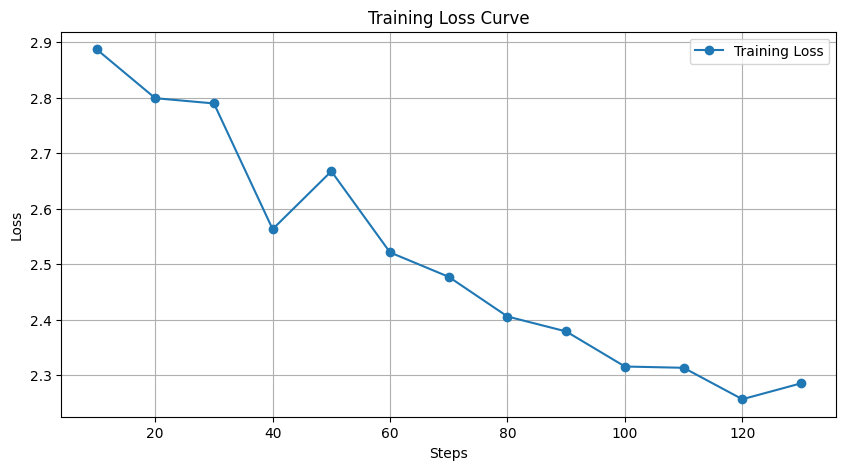

In [ ]:
import matplotlib.pyplot as plt

# Extract log history
history = trainer.state.log_history
steps = [x['step'] for x in history if 'loss' in x]
loss = [x['loss'] for x in history if 'loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, loss, label='Training Loss', marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import gc
import torch

def evaluate_sample(index):
    # 1. Clear GPU memory cache before each generation
    gc.collect()
    torch.cuda.empty_cache()

    # Accessing the 'train' split of the DatasetDict
    sample = dataset['train'][index]
    prompt = f"<|im_start|>system\nYou are an expert resume parser. Extract structured information and return ONLY JSON.<|im_end|>\n<|im_start|>user\nResume:\n{sample['input']}<|im_end|>\n<|im_start|>assistant\n"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # 2. Use inference mode for better memory efficiency
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=500,
            temperature=0.1,
            use_cache=True # Faster inference
        )

    decoded = tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True)

    print(f"--- Sample {index} ---")
    print(f"Target: {json.dumps(sample['output'], indent=2)}")
    print(f"Model: {decoded}")
    print("-" * 30)

# Evaluate 3 samples from the training set
for i in range(0, 3):
    try:
        evaluate_sample(i)
    except Exception as e:
        print(f"Error on sample {i}: {e}")
        torch.cuda.empty_cache()

--- Sample 0 ---
Target: {
  "name": "Nikith Reddy Email: Nikith.k25@gmail.com Phone no: (510)-944-7683 SUMMARY: Having 9 years of IT experience in Object Oriented development, testing, and support of Enterprise applications using Java/J2EE technologies. Extensive experience in core Java and Advanced Java frameworks such as Spring (MVC, IoC, AOP, Security, DI, JDBC), Servlets, ORM tools (Java Persistence API, Hibernate and MyBatis), along with other java technologies like EJB, Junit, Apache Struts 2, Apache Axis, JFC (SWING, AWT, Java 2D), JSTL and log4j. Excellent Proficiency in frontend development using HTML, CSS, JavaScript, AngularJS, Backbone.js, jQuery, Bootstrap, AJAX and Adobe Flash. Expertise in developing and registering web services using JAX-RPC, JAX-WS, SAAJ, JAX-RS, SOAP, REST, WSDL, UDDI registry along with developing micro services and other middleware. Extensive experience with building cloud based applications. Has vast experience in relational databases like Oracle,

### 🧪 Final Inference Test
Now that the model is trained, let's run a manual test on a custom sample to verify the structured output.

In [ ]:
sample_text = """
John Doe
Bachelor of Computer Science
5 years Python and SQL experience
Worked with Power BI and Tableau
"""

prompt = f"""
<|im_start|>system
You are an expert resume parser. Return STRICT JSON only.<|im_end|>
<|im_start|>user
Resume:
{sample_text}<|im_end|>
<|im_start|>assistant
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

# Set model to evaluation mode
model.eval()

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.1,
        do_sample=True
    )

response = tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True)
print(response)

{"NAME": "John Doe", "PROFESSIONAL SUMMARY": "5 years of IT experience in all phases of Software Development Life Cycle (SDLC) including Analysis, Design, Implementation and Testing of Web-based and Client-Server applications using Java/J2EE technologies. Expertise in developing web based applications using HTML, DHTML, CSS, JavaScript, JQuery, Ajax, AngularJS, Node JS, Backbone JS, React JS, Bootstrap, jQuery UI, Ext JS, JSON, XML, XSLT, AJAX, JSP, Servlets, EJB, Struts, Spring, Hibernate, JDBC, JMS, JNDI, RMI, JAXP, JUnit, Log4J, Test Driven Development (TDD), SOAP, WSDL, UDDI, RESTful, Web Services, Apache Camel, Apache Axis, Apache CAMEL, Apache CXF, Apache Kafka, Apache Tomcat, Apache POJO, Apache Solr, Apache Spark


## 📊 Comprehensive Evaluation: Base Model vs Fine-Tuned Model

This section evaluates **both** models across the full test split and computes:
- ✅ JSON Validity Rate
- 🎯 Field-Level Accuracy (name, skills, education, experience_years)
- 🔁 Exact Match Score
- 📋 Side-by-side comparison table
- 📈 Comparison charts
- 💾 Results saved to CSV


In [ ]:
# ── 1. Load Base Model (no LoRA adapters) ────────────────────────────────────
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import gc

model_id = "Qwen/Qwen2-1.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading base tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model (no LoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
base_model.eval()
print("✔ Base model loaded")


Loading base tokenizer...
Loading base model (no LoRA)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✔ Base model loaded


In [ ]:
# ── 2. Load Fine-Tuned Model (LoRA adapters) ─────────────────────────────────
from peft import PeftModel

save_path = "./fine_tuned_qwen_resumes"   # same path used after training

print("Loading fine-tuned model...")
ft_base = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
ft_model = PeftModel.from_pretrained(ft_base, save_path)
ft_model.eval()
print("✔ Fine-tuned model loaded")


Loading fine-tuned model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✔ Fine-tuned model loaded


In [ ]:
# ── 3. Shared Inference Helper ────────────────────────────────────────────────
import re, json as _json

SYSTEM_PROMPT = (
    "You are an expert resume parser. Extract the following fields into a "
    "valid JSON object: 'name', 'skills' (list), 'education', and "
    "'experience_years' (integer). Return ONLY the JSON object."
)

def build_prompt(resume_text: str) -> str:
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\nResume:\n{resume_text}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

def run_inference(mdl, text: str, max_new_tokens: int = 300) -> str:
    """Run one forward pass and return raw decoded string."""
    gc.collect()
    torch.cuda.empty_cache()
    prompt = build_prompt(text)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.inference_mode():
        out = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            repetition_penalty=1.1,
            use_cache=True
        )
    decoded = tokenizer.decode(
        out[0][len(inputs.input_ids[0]):], skip_special_tokens=True
    )
    return decoded.strip()

def extract_json(raw: str) -> dict | None:
    """Try to pull a JSON object out of model output. Returns dict or None."""
    # Try full string first
    try:
        return _json.loads(raw)
    except Exception:
        pass
    # Regex: find outermost { … }
    m = re.search(r'\{.*?\}', raw, re.DOTALL)
    if m:
        try:
            return _json.loads(m.group(0))
        except Exception:
            pass
    # Basic repair: open brace but no close
    if '{' in raw and '}' not in raw:
        try:
            return _json.loads(raw[raw.find('{'):] + '}')
        except Exception:
            pass
    return None

print("✔ Inference helpers defined")


✔ Inference helpers defined


In [ ]:
# ── 4. Evaluation Metrics ─────────────────────────────────────────────────────

REQUIRED_FIELDS = ["name", "skills", "education", "experience_years"]

def is_valid_json(parsed) -> bool:
    return parsed is not None

def field_present_score(parsed: dict | None) -> float:
    """Fraction of required fields present (and non-empty) in the output."""
    if parsed is None:
        return 0.0
    present = sum(
        1 for f in REQUIRED_FIELDS
        if f in parsed and parsed[f] not in (None, "", [], 0)
    )
    return present / len(REQUIRED_FIELDS)

def field_accuracy(pred: dict | None, gt: dict) -> dict:
    """Per-field match between prediction and ground-truth."""
    if pred is None:
        return {f: 0 for f in REQUIRED_FIELDS}
    scores = {}
    for field in REQUIRED_FIELDS:
        p_val = pred.get(field)
        g_val = gt.get(field)
        if field == "skills":
            # Jaccard similarity on skill sets (lowercased)
            p_set = set(str(x).lower() for x in (p_val or []))
            g_set = set(str(x).lower() for x in (g_val or []))
            union = p_set | g_set
            scores[field] = len(p_set & g_set) / len(union) if union else 1.0
        elif field == "experience_years":
            scores[field] = 1.0 if int(p_val or 0) == int(g_val or 0) else 0.0
        else:
            scores[field] = 1.0 if str(p_val or "").strip().lower() == str(g_val or "").strip().lower() else 0.0
    return scores

def exact_match(pred: dict | None, gt: dict) -> bool:
    """True only if ALL fields match exactly."""
    if pred is None:
        return False
    fa = field_accuracy(pred, gt)
    return all(v == 1.0 for v in fa.values())

print("✔ Metrics defined")


✔ Metrics defined


In [ ]:
# ── 5. Run Evaluation on Test Split ───────────────────────────────────────────
import pandas as pd
from tqdm.auto import tqdm

# Use the held-out test split created during dataset preparation
test_samples = dataset["test"]   # 10% split (seed=42)
N = len(test_samples)
print(f"Evaluating on {N} test samples…")

rows = []

for i in tqdm(range(N), desc="Evaluating"):
    sample   = test_samples[i]
    text     = sample["input"]
    gt       = sample["output"]          # ground-truth dict

    # ---- Base model ----
    raw_base   = run_inference(base_model, text)
    pred_base  = extract_json(raw_base)
    fa_base    = field_accuracy(pred_base, gt)

    # ---- Fine-tuned model ----
    raw_ft     = run_inference(ft_model,   text)
    pred_ft    = extract_json(raw_ft)
    fa_ft      = field_accuracy(pred_ft, gt)

    row = {
        "sample_id"           : i,
        # JSON validity
        "base_json_valid"     : int(is_valid_json(pred_base)),
        "ft_json_valid"       : int(is_valid_json(pred_ft)),
        # Field presence
        "base_field_presence" : field_present_score(pred_base),
        "ft_field_presence"   : field_present_score(pred_ft),
        # Per-field accuracy
        **{f"base_acc_{f}": fa_base[f] for f in REQUIRED_FIELDS},
        **{f"ft_acc_{f}"  : fa_ft[f]   for f in REQUIRED_FIELDS},
        # Exact match
        "base_exact_match"    : int(exact_match(pred_base, gt)),
        "ft_exact_match"      : int(exact_match(pred_ft,   gt)),
        # Raw outputs (for inspection)
        "raw_base"            : raw_base,
        "raw_ft"              : raw_ft,
    }
    rows.append(row)

results_df = pd.DataFrame(rows)
print("\n✔ Evaluation complete")
print(results_df.shape)


Evaluating on 23 test samples…


Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]


✔ Evaluation complete
(23, 17)


In [ ]:
# ── 6. Summary Comparison Table ───────────────────────────────────────────────
import pandas as pd

def make_summary(df: pd.DataFrame) -> pd.DataFrame:
    metrics = {
        "JSON Validity (%)": (
            df["base_json_valid"].mean() * 100,
            df["ft_json_valid"].mean()   * 100
        ),
        "Field Presence (%)": (
            df["base_field_presence"].mean() * 100,
            df["ft_field_presence"].mean()   * 100
        ),
        "Exact Match (%)": (
            df["base_exact_match"].mean() * 100,
            df["ft_exact_match"].mean()   * 100
        ),
    }
    for f in REQUIRED_FIELDS:
        metrics[f"Field Acc – {f} (%)"] = (
            df[f"base_acc_{f}"].mean() * 100,
            df[f"ft_acc_{f}"].mean()   * 100,
        )
    summary = pd.DataFrame(
        metrics, index=["Base Model", "Fine-Tuned Model"]
    ).T
    summary["Δ (FT − Base)"] = summary["Fine-Tuned Model"] - summary["Base Model"]
    return summary.round(2)

summary_df = make_summary(results_df)
print("=" * 60)
print("         BASE MODEL vs FINE-TUNED MODEL — Summary")
print("=" * 60)
print(summary_df.to_string())
print("=" * 60)


         BASE MODEL vs FINE-TUNED MODEL — Summary
                                  Base Model  Fine-Tuned Model  Δ (FT − Base)
JSON Validity (%)                      60.87             52.17          -8.70
Field Presence (%)                     56.52             45.65         -10.87
Exact Match (%)                         0.00              0.00           0.00
Field Acc – name (%)                    0.00              4.35           4.35
Field Acc – skills (%)                  5.14              0.00          -5.14
Field Acc – education (%)               0.00              0.00           0.00
Field Acc – experience_years (%)       52.17             39.13         -13.04


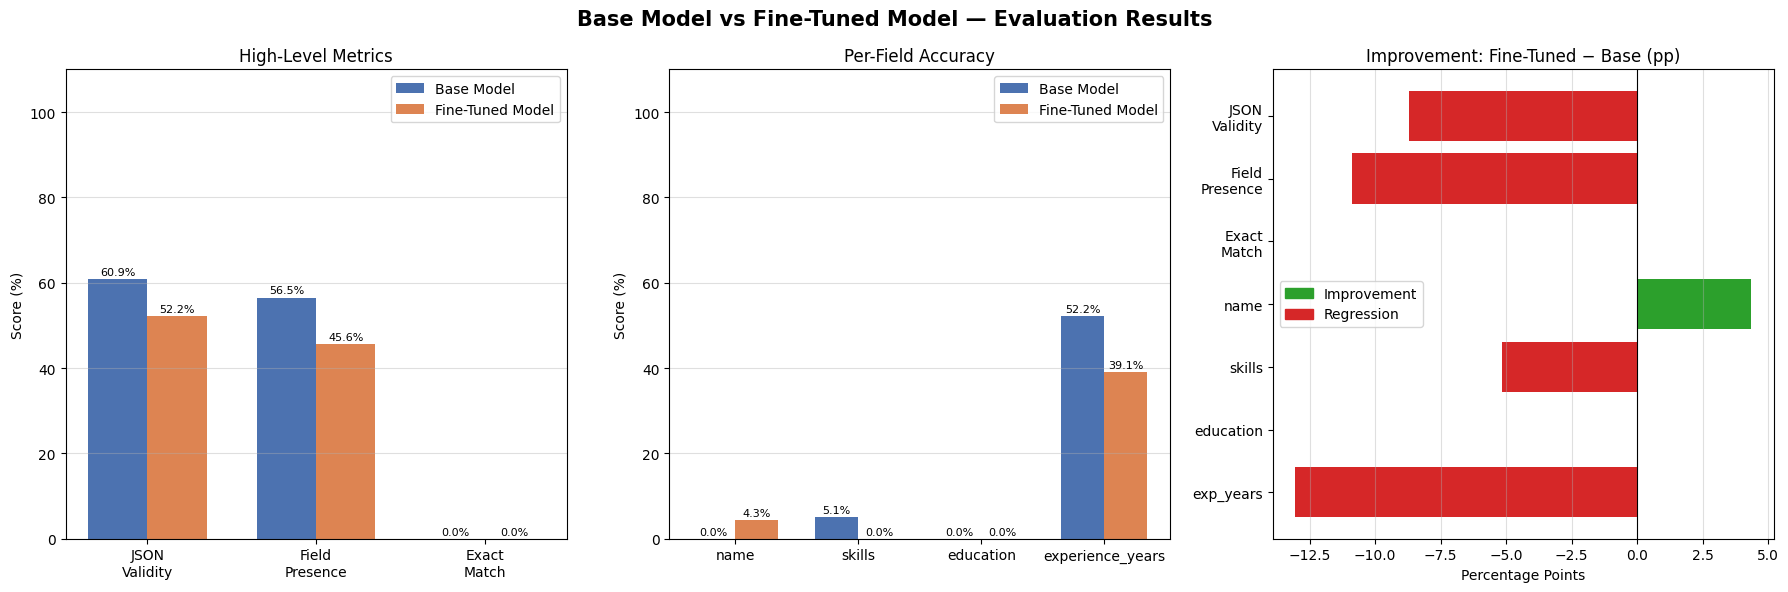

✔ Chart saved as evaluation_comparison.png


In [ ]:
# ── 7. Comparison Charts ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BASE_COLOR = "#4C72B0"
FT_COLOR   = "#DD8452"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Base Model vs Fine-Tuned Model — Evaluation Results", fontsize=15, fontweight="bold")

# ── Chart 1: High-level metrics bar chart ─────────────────────────────────
ax1 = axes[0]
high_level_metrics = ["JSON Validity (%)", "Field Presence (%)", "Exact Match (%)"]
base_vals = [summary_df.loc[m, "Base Model"]    for m in high_level_metrics]
ft_vals   = [summary_df.loc[m, "Fine-Tuned Model"] for m in high_level_metrics]
x = np.arange(len(high_level_metrics))
w = 0.35
ax1.bar(x - w/2, base_vals, w, label="Base Model",     color=BASE_COLOR)
ax1.bar(x + w/2, ft_vals,   w, label="Fine-Tuned Model", color=FT_COLOR)
ax1.set_title("High-Level Metrics")
ax1.set_xticks(x)
ax1.set_xticklabels(["JSON\nValidity", "Field\nPresence", "Exact\nMatch"], fontsize=10)
ax1.set_ylabel("Score (%)")
ax1.set_ylim(0, 110)
ax1.legend()
ax1.grid(axis="y", alpha=0.4)
for bar in ax1.patches:
    h = bar.get_height()
    ax1.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

# ── Chart 2: Per-field accuracy ───────────────────────────────────────────
ax2 = axes[1]
field_metric_labels = [f"Field Acc – {f} (%)" for f in REQUIRED_FIELDS]
base_field = [summary_df.loc[m, "Base Model"]       for m in field_metric_labels]
ft_field   = [summary_df.loc[m, "Fine-Tuned Model"] for m in field_metric_labels]
x2 = np.arange(len(REQUIRED_FIELDS))
ax2.bar(x2 - w/2, base_field, w, label="Base Model",     color=BASE_COLOR)
ax2.bar(x2 + w/2, ft_field,   w, label="Fine-Tuned Model", color=FT_COLOR)
ax2.set_title("Per-Field Accuracy")
ax2.set_xticks(x2)
ax2.set_xticklabels(REQUIRED_FIELDS, fontsize=10)
ax2.set_ylabel("Score (%)")
ax2.set_ylim(0, 110)
ax2.legend()
ax2.grid(axis="y", alpha=0.4)
for bar in ax2.patches:
    h = bar.get_height()
    ax2.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

# ── Chart 3: Delta improvement ────────────────────────────────────────────
ax3 = axes[2]
all_metric_labels = high_level_metrics + field_metric_labels
delta_vals = [summary_df.loc[m, "Δ (FT − Base)"] for m in all_metric_labels]
short_labels = ["JSON\nValidity", "Field\nPresence", "Exact\nMatch",
                "name", "skills", "education", "exp_years"]
colors = ["#2ca02c" if d >= 0 else "#d62728" for d in delta_vals]
ax3.barh(short_labels[::-1], delta_vals[::-1], color=colors[::-1])
ax3.axvline(0, color="black", linewidth=0.8)
ax3.set_title("Improvement: Fine-Tuned − Base (pp)")
ax3.set_xlabel("Percentage Points")
ax3.grid(axis="x", alpha=0.4)
pos_patch = mpatches.Patch(color="#2ca02c", label="Improvement")
neg_patch = mpatches.Patch(color="#d62728", label="Regression")
ax3.legend(handles=[pos_patch, neg_patch])

plt.tight_layout()
plt.savefig("evaluation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Chart saved as evaluation_comparison.png")


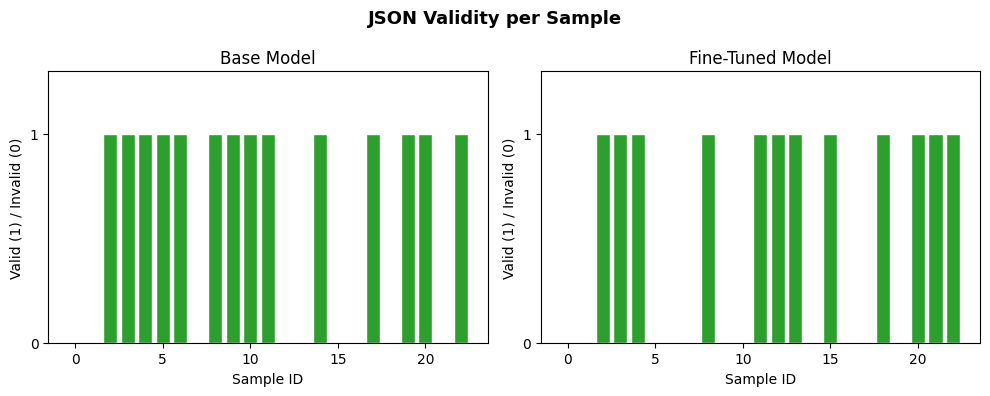

✔ Per-sample validity chart saved


In [ ]:
# ── 8. Per-Sample JSON Validity Detail ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("JSON Validity per Sample", fontsize=13, fontweight="bold")

sample_ids = results_df["sample_id"].tolist()
for ax, col, title, color in [
    (ax1, "base_json_valid", "Base Model",     BASE_COLOR),
    (ax2, "ft_json_valid",   "Fine-Tuned Model", FT_COLOR),
]:
    vals = results_df[col].tolist()
    bar_colors = ["#2ca02c" if v else "#d62728" for v in vals]
    ax.bar(sample_ids, vals, color=bar_colors, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Sample ID")
    ax.set_ylabel("Valid (1) / Invalid (0)")
    ax.set_ylim(0, 1.3)
    ax.set_yticks([0, 1])

plt.tight_layout()
plt.savefig("json_validity_per_sample.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Per-sample validity chart saved")


In [ ]:
# ── 9. Save All Results to CSV ────────────────────────────────────────────────
import pandas as pd

# Full results (one row per test sample)
results_df.to_csv("evaluation_results.csv", index=False)

# Summary table
summary_df.to_csv("evaluation_summary.csv")

print("✔ Saved: evaluation_results.csv")
print("✔ Saved: evaluation_summary.csv")
print()
print("Columns in evaluation_results.csv:")
for col in results_df.columns:
    print(f"  • {col}")


✔ Saved: evaluation_results.csv
✔ Saved: evaluation_summary.csv

Columns in evaluation_results.csv:
  • sample_id
  • base_json_valid
  • ft_json_valid
  • base_field_presence
  • ft_field_presence
  • base_acc_name
  • base_acc_skills
  • base_acc_education
  • base_acc_experience_years
  • ft_acc_name
  • ft_acc_skills
  • ft_acc_education
  • ft_acc_experience_years
  • base_exact_match
  • ft_exact_match
  • raw_base
  • raw_ft


In [ ]:
# ── 10. Inspect Individual Sample Outputs ────────────────────────────────────
import json as _json

def inspect_sample(i: int):
    row    = results_df.iloc[i]
    sample = dataset["test"][int(row["sample_id"])]
    gt     = sample["output"]

    print(f"\n{'='*60}")
    print(f"  Sample {i:>3d} | Resume (first 200 chars):")
    print(f"  {sample['input'][:200].strip()}")
    print(f"{'='*60}")

    print("\n  Ground Truth:")
    print(f"    {_json.dumps(gt, indent=4)}")

    print("\n  Base Model Output (raw):")
    print(f"    {row['raw_base'][:300]}")
    print(f"    → JSON valid: {'✅' if row['base_json_valid'] else '❌'}   Exact match: {'✅' if row['base_exact_match'] else '❌'}")

    print("\n  Fine-Tuned Model Output (raw):")
    print(f"    {row['raw_ft'][:300]}")
    print(f"    → JSON valid: {'✅' if row['ft_json_valid'] else '❌'}   Exact match: {'✅' if row['ft_exact_match'] else '❌'}")
    print()

# Inspect first 3 test samples
for idx in range(min(3, len(results_df))):
    inspect_sample(idx)



  Sample   0 | Resume (first 200 chars):
  Madhuri (720) 722-0838 madhurir1702@gmail.com Objective: To work in the most challenging position with an organization that provides ample opportunities to learn and to contribute for the growth of an

  Ground Truth:
    {
    "name": "Madhuri (720) 722-0838 madhurir1702@gmail.com Objective: To work in the most challenging position with an organization that provides ample opportunities to learn and to contribute for the growth of an organization. Possess 8 years of professional IT experience in designing and developing Web based and Enterprise applications using JAVA/J2EE technologies in Telecom, Financial, Insurance and Digital domains. Professional Summary: Experienced in all phases of Software Development Life Cycle (SDLC) including Analysis, Design, and Development, Debugging, Support, Integration, Maintenance, and Enhancements of Java/J2EE Applications. Experience in working in environments using Agile (SCRUM) and Waterfall development 

In [ ]:
!pip install pypdf

In [ ]:
import gradio as gr
import json
import pandas as pd
from pypdf import PdfReader
import docx
import os
import torch
import re

def extract_text_from_file(file_path):
    if file_path is None:
        return ""
    ext = os.path.splitext(file_path)[1].lower()
    text = ""
    try:
        if ext == ".pdf":
            reader = PdfReader(file_path)
            for page in reader.pages:
                page_text = page.extract_text()
                if page_text: text += page_text + "\n"
        elif ext == ".docx":
            doc = docx.Document(file_path)
            for para in doc.paragraphs: text += para.text + "\n"
        else: return "Error: Unsupported format."
    except Exception as e: return f"Error: {e}"
    return text.strip()

def parse_resume(file_path, text_input):
    raw_text = text_input if text_input.strip() else extract_text_from_file(file_path)
    if not raw_text or "Error:" in raw_text: return raw_text, "{}", pd.DataFrame()

    # More explicit system prompt to prevent field merging
    system_prompt = "You are an expert resume parser. Extract the following fields into a valid JSON object: 'name', 'skills' (list), 'education', and 'experience_years' (integer). Do NOT put the entire text into one field."

    prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n<|im_start|>user\nResume:\n{raw_text}<|im_end|>\n<|im_start|>assistant\n"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.inference_mode():
        outputs = model.generate(**inputs, max_new_tokens=512, temperature=0.1, repetition_penalty=1.1)

    output = tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True).strip()

    try:
        # Robust JSON extraction
        json_match = re.search(r'\{.*\}', output, re.DOTALL)
        if json_match:
            clean_json = json_match.group(0)
        else:
            # If no closing brace, try to find the start and add one (basic repair)
            if '{' in output and '}' not in output:
                clean_json = output[output.find('{'):] + '}'
            else:
                clean_json = output

        parsed = json.loads(clean_json)
        return output, json.dumps(parsed, indent=2), pd.DataFrame([parsed])
    except:
        parsed = {"error": "Parsing Failed - Model outputted unstructured text", "raw_output": output}
        return output, json.dumps(parsed, indent=2), pd.DataFrame([parsed])

with gr.Blocks() as demo:
    gr.Markdown("# 📄 AI Resume Parser")
    with gr.Row():
        with gr.Column():
            file_in = gr.File(label="Upload")
            text_in = gr.Textbox(label="Paste Text", lines=5)
            btn = gr.Button("Parse", variant="primary")
        with gr.Column():
            json_out = gr.Code(label="JSON Output", language="json")
            table_out = gr.Dataframe(label="Table View")
    btn.click(parse_resume, [file_in, text_in], [text_in, json_out, table_out])

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bd912d2f31c3580e6f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
